In [43]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

print(" All ML libraries imported successfully!")
print(" Ready to train models!")

 All ML libraries imported successfully!
 Ready to train models!


In [42]:

PROCESSED_PATH = Path("../dataset/processed/")
MODELS_PATH = Path("../backend/ml/models/")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

cards_df = pd.read_csv(PROCESSED_PATH / "cards_cleaned.csv")
decks_df = pd.read_csv(PROCESSED_PATH / "decks_cleaned.csv")

print(" Data loaded!")
print(f" Cards: {cards_df.shape}")
print(f" Decks: {decks_df.shape}")
print(f" Models will be saved to: {MODELS_PATH.absolute()}")

 Data loaded!
 Cards: (121, 16)
 Decks: (480, 18)
 Models will be saved to: e:\Clash Royale\notebooks\..\backend\ml\models


In [41]:

print("⚡ CREATING DECK FEATURES FROM CARDS")
print("=" * 60)


card_lookup = cards_df.set_index('name').to_dict('index')

def get_deck_features(row):
    """Calculate aggregate features for a deck."""
    deck_cards = [row[f'card_{i}'] for i in range(1, 9)]
    
    elixir_costs = []
    damages = []
    hps = []
    win_rates = []
    usage_rates = []
    rarities = []
    types = []
    
    for card in deck_cards:
        if card in card_lookup:
            info = card_lookup[card]
            elixir_costs.append(info['elixir_cost'])
            damages.append(info['damage'])
            hps.append(info['hitpoints'])
            win_rates.append(info['win_rate'])
            usage_rates.append(info['usage_rate'])
            rarities.append(info['rarity'])
            types.append(info['type'])
    
    return pd.Series({
        'total_elixir': sum(elixir_costs),
        'avg_damage': np.mean(damages) if damages else 0,
        'avg_hp': np.mean(hps) if hps else 0,
        'avg_card_win_rate': np.mean(win_rates) if win_rates else 0,
        'avg_card_usage': np.mean(usage_rates) if usage_rates else 0,
        'num_legendary': rarities.count('Legendary'),
        'num_epic': rarities.count('Epic'),
        'num_rare': rarities.count('Rare'),
        'num_common': rarities.count('Common'),
        'num_troops': types.count('Troop'),
        'num_spells': types.count('Spell'),
        'num_buildings': types.count('Building'),
    })


print(" Processing 500 decks... (~10 seconds)")
deck_features = decks_df.apply(get_deck_features, axis=1)
decks_full = pd.concat([decks_df, deck_features], axis=1)

print(f"\n Created {len(deck_features.columns)} new features!")
print(f" Total columns now: {len(decks_full.columns)}")
decks_full.head()

⚡ CREATING DECK FEATURES FROM CARDS
 Processing 500 decks... (~10 seconds)

 Created 12 new features!
 Total columns now: 30


,deck_id,deck_name,tier,source,card_1,card_2,card_3,card_4,card_5,card_6,...,avg_hp,avg_card_win_rate,avg_card_usage,num_legendary,num_epic,num_rare,num_common,num_troops,num_spells,num_buildings
0,1,2.6 Hog Cycle,S,Classic competitive deck,Hog Rider,Musketeer,Ice Spirit,Skeletons,Fireball,The Log,...,608.5,54.4,19.95625,1.0,0.0,4.0,3.0,5.0,2.0,1.0
1,2,2.6 Hog Cycle,S,Classic competitive deck,Hog Rider,Musketeer,Ice Spirit,Skeletons,Fireball,The Log,...,608.5,54.4,19.95625,1.0,0.0,4.0,3.0,5.0,2.0,1.0
2,3,2.6 Hog Cycle,S,Classic competitive deck,Hog Rider,Musketeer,Ice Spirit,Skeletons,Fireball,The Log,...,608.5,54.4,19.95625,1.0,0.0,4.0,3.0,5.0,2.0,1.0
3,4,2.6 Hog Cycle,S,Classic competitive deck,Hog Rider,Musketeer,Ice Spirit,Skeletons,Fireball,The Log,...,608.5,54.4,19.95625,1.0,0.0,4.0,3.0,5.0,2.0,1.0
4,5,2.6 Hog Cycle,S,Classic competitive deck,Hog Rider,Musketeer,Ice Spirit,Skeletons,Fireball,The Log,...,608.5,54.4,19.95625,1.0,0.0,4.0,3.0,5.0,2.0,1.0


In [40]:

FEATURE_COLS = [
    'avg_elixir', 'total_elixir', 'avg_damage', 'avg_hp',
    'avg_card_win_rate', 'avg_card_usage',
    'num_legendary', 'num_epic', 'num_rare', 'num_common',
    'num_troops', 'num_spells', 'num_buildings'
]

X = decks_full[FEATURE_COLS]
y_winrate = decks_full['win_rate']
y_archetype = decks_full['archetype']

print(" Features prepared!")
print(f" X shape: {X.shape}")
print(f" y_winrate shape: {y_winrate.shape}")
print(f"\n Feature columns:")
for col in FEATURE_COLS:
    print(f"   • {col}")

 Features prepared!
 X shape: (480, 13)
 y_winrate shape: (480,)

 Feature columns:
   • avg_elixir
   • total_elixir
   • avg_damage
   • avg_hp
   • avg_card_win_rate
   • avg_card_usage
   • num_legendary
   • num_epic
   • num_rare
   • num_common
   • num_troops
   • num_spells
   • num_buildings


In [39]:

X_train, X_test, y_train_wr, y_test_wr = train_test_split(
    X, y_winrate, test_size=0.2, random_state=42
)


_, _, y_train_arch, y_test_arch = train_test_split(
    X, y_archetype, test_size=0.2, random_state=42
)

print(" Data split complete!")
print(f"Training set: {X_train.shape[0]} decks (80%)")
print(f"Testing set:  {X_test.shape[0]} decks (20%)")

 Data split complete!
Training set: 384 decks (80%)
Testing set:  96 decks (20%)


In [38]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


joblib.dump(scaler, MODELS_PATH / "scaler.pkl")
print(" Features scaled & scaler saved!")
print(f" Saved: {MODELS_PATH / 'scaler.pkl'}")

 Features scaled & scaler saved!
 Saved: ..\backend\ml\models\scaler.pkl


In [ ]:

print(" TRAINING MODEL 1: WIN RATE PREDICTOR")
print("=" * 60)


win_rate_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

win_rate_model.fit(X_train_scaled, y_train_wr)


y_pred_wr = win_rate_model.predict(X_test_scaled)


mae = mean_absolute_error(y_test_wr, y_pred_wr)
rmse = np.sqrt(mean_squared_error(y_test_wr, y_pred_wr))
r2 = r2_score(y_test_wr, y_pred_wr)

print(f"\n Model Performance:")
print(f"   • MAE:  {mae:.2f}")
print(f"   • RMSE: {rmse:.2f}")
print(f"   • R²:   {r2:.4f}")


joblib.dump(win_rate_model, MODELS_PATH / "win_rate_predictor.pkl")
print(f"\n Model saved: win_rate_predictor.pkl")

 TRAINING MODEL 1: WIN RATE PREDICTOR

 Model Performance:
   • MAE:  0.90
   • RMSE: 1.09
   • R²:   0.7213

 Model saved: win_rate_predictor.pkl


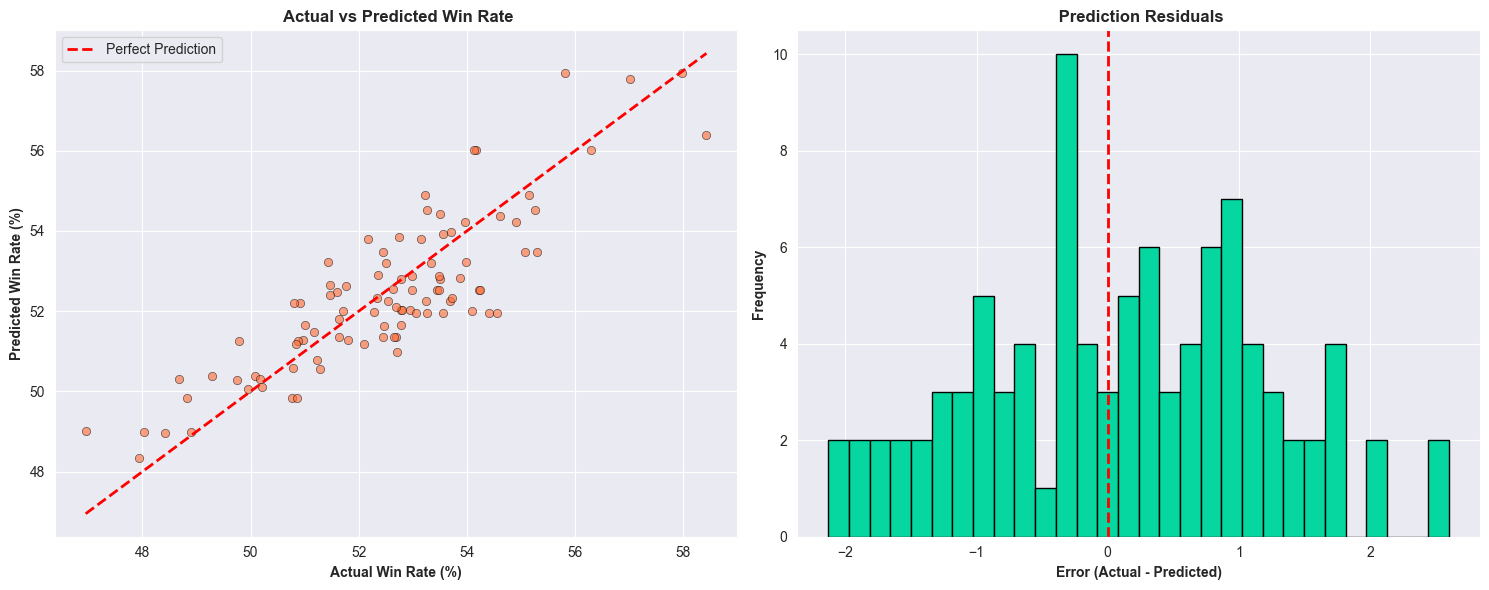

In [36]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].scatter(y_test_wr, y_pred_wr, alpha=0.6, color='#FF6B35',
                edgecolors='black', linewidth=0.5)
axes[0].plot([y_test_wr.min(), y_test_wr.max()],
             [y_test_wr.min(), y_test_wr.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(' Actual vs Predicted Win Rate', fontweight='bold')
axes[0].set_xlabel('Actual Win Rate (%)', fontweight='bold')
axes[0].set_ylabel('Predicted Win Rate (%)', fontweight='bold')
axes[0].legend()


residuals = y_test_wr - y_pred_wr
axes[1].hist(residuals, bins=30, color='#06D6A0', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(' Prediction Residuals', fontweight='bold')
axes[1].set_xlabel('Error (Actual - Predicted)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')

plt.tight_layout()
plt.show()

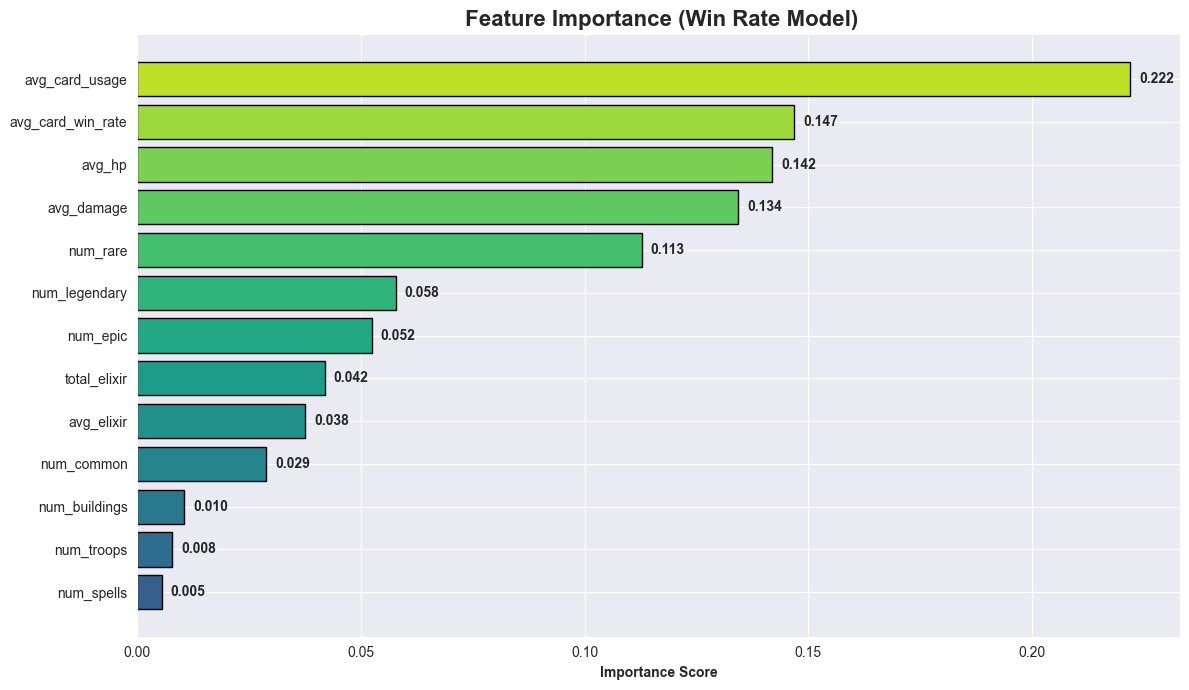

In [35]:

feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': win_rate_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'],
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance))),
               edgecolor='black', linewidth=1)

for bar, val in zip(bars, feature_importance['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')

ax.set_title(' Feature Importance (Win Rate Model)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Importance Score', fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:

print(" TRAINING MODEL 2: DECK STRENGTH SCORER")
print("=" * 60)


decks_full['strength_score'] = (
    (decks_full['win_rate'] * 0.6) +
    (decks_full['avg_card_win_rate'] * 0.25) +
    (decks_full['avg_card_usage'] * 0.15)
).clip(0, 100)

y_strength = decks_full['strength_score']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_strength, test_size=0.2, random_state=42
)

X_train_s_scaled = scaler.fit_transform(X_train_s)
X_test_s_scaled = scaler.transform(X_test_s)


strength_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

strength_model.fit(X_train_s_scaled, y_train_s)
y_pred_s = strength_model.predict(X_test_s_scaled)


mae_s = mean_absolute_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"\n Model Performance:")
print(f"   • MAE: {mae_s:.2f}")
print(f"   • R²:  {r2_s:.4f}")


joblib.dump(strength_model, MODELS_PATH / "deck_strength_scorer.pkl")
print(f"\n Model saved: deck_strength_scorer.pkl")

 TRAINING MODEL 2: DECK STRENGTH SCORER

 Model Performance:
   • MAE: 0.53
   • R²:  0.7809

 Model saved: deck_strength_scorer.pkl


In [33]:

print("TRAINING MODEL 3: ARCHETYPE CLASSIFIER")
print("=" * 60)


label_encoder = LabelEncoder()
y_arch_encoded = label_encoder.fit_transform(y_archetype)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_arch_encoded, test_size=0.2, random_state=42
)

X_train_a_scaled = scaler.fit_transform(X_train_a)
X_test_a_scaled = scaler.transform(X_test_a)


archetype_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

archetype_model.fit(X_train_a_scaled, y_train_a)
y_pred_a = archetype_model.predict(X_test_a_scaled)


accuracy = accuracy_score(y_test_a, y_pred_a)

print(f"\nModel Performance:")
print(f"   • Accuracy: {accuracy * 100:.2f}%")

print(f"\n Classification Report:")
print(classification_report(y_test_a, y_pred_a,
                            target_names=label_encoder.classes_))


joblib.dump(archetype_model, MODELS_PATH / "archetype_classifier.pkl")
joblib.dump(label_encoder, MODELS_PATH / "label_encoder.pkl")
print(f" Models saved!")

TRAINING MODEL 3: ARCHETYPE CLASSIFIER

Model Performance:
   • Accuracy: 100.00%

 Classification Report:
              precision    recall  f1-score   support

    Beatdown       1.00      1.00      1.00        49
     Control       1.00      1.00      1.00        14
       Cycle       1.00      1.00      1.00        26
       Siege       1.00      1.00      1.00         7

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96

 Models saved!


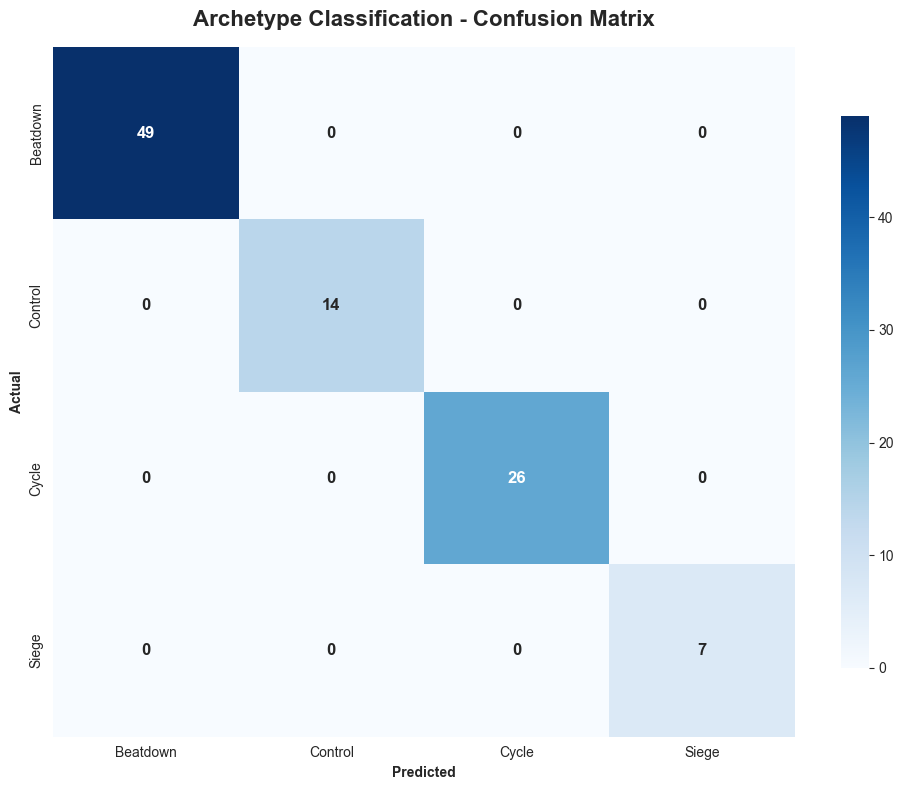

In [32]:

cm = confusion_matrix(y_test_a, y_pred_a)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontweight': 'bold', 'fontsize': 12}
)

plt.title('Archetype Classification - Confusion Matrix',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:

print(" TESTING MODELS WITH A SAMPLE DECK")
print("=" * 60)


sample_deck = ['Hog Rider', 'Musketeer', 'Ice Spirit', 'Skeletons',
               'Fireball', 'The Log', 'Cannon', 'Ice Golem']

print(f" Sample Deck:")
for i, card in enumerate(sample_deck, 1):
    print(f"   {i}. {card}")

avg_elixir = np.mean([
    card_lookup[c]['elixir_cost'] for c in sample_deck if c in card_lookup
])


sample_features = {
    'card_1': sample_deck[0], 'card_2': sample_deck[1],
    'card_3': sample_deck[2], 'card_4': sample_deck[3],
    'card_5': sample_deck[4], 'card_6': sample_deck[5],
    'card_7': sample_deck[6], 'card_8': sample_deck[7],
}


sample_extracted = get_deck_features(pd.Series(sample_features))


sample_extracted['avg_elixir'] = avg_elixir


sample_input = pd.DataFrame([sample_extracted])[FEATURE_COLS]
sample_scaled = scaler.transform(sample_input)


pred_winrate = win_rate_model.predict(sample_scaled)[0]
pred_strength = strength_model.predict(sample_scaled)[0]
pred_arch_idx = archetype_model.predict(sample_scaled)[0]
pred_archetype = label_encoder.inverse_transform([pred_arch_idx])[0]

print(f"\n PREDICTIONS:")
print(f"   • Predicted Win Rate:    {pred_winrate:.2f}%")
print(f"   • Predicted Strength:    {pred_strength:.2f}/100")
print(f"   • Predicted Archetype:   {pred_archetype}")
print(f"   • Average Elixir:        {avg_elixir:.2f}")

 TESTING MODELS WITH A SAMPLE DECK
 Sample Deck:
   1. Hog Rider
   2. Musketeer
   3. Ice Spirit
   4. Skeletons
   5. Fireball
   6. The Log
   7. Cannon
   8. Ice Golem

 PREDICTIONS:
   • Predicted Win Rate:    57.94%
   • Predicted Strength:    51.38/100
   • Predicted Archetype:   Cycle
   • Average Elixir:        2.62


In [29]:

print("=" * 70)
print(" ML MODEL TRAINING COMPLETE!")
print("=" * 70)

print(f"""
 MODEL 1: WIN RATE PREDICTOR
   • Algorithm:  Random Forest Regressor
   • MAE:        {mae:.2f}
   • R² Score:   {r2:.4f}
   • Saved as:   win_rate_predictor.pkl

 MODEL 2: DECK STRENGTH SCORER
   • Algorithm:  Gradient Boosting Regressor
   • MAE:        {mae_s:.2f}
   • R² Score:   {r2_s:.4f}
   • Saved as:   deck_strength_scorer.pkl

 MODEL 3: ARCHETYPE CLASSIFIER
   • Algorithm:  Random Forest Classifier
   • Accuracy:   {accuracy * 100:.2f}%
   • Saved as:   archetype_classifier.pkl

 SUPPORTING FILES:
   • scaler.pkl
   • label_encoder.pkl

 ALL FILES SAVED IN: backend/ml/models/
""")

 ML MODEL TRAINING COMPLETE!

 MODEL 1: WIN RATE PREDICTOR
   • Algorithm:  Random Forest Regressor
   • MAE:        0.90
   • R² Score:   0.7213
   • Saved as:   win_rate_predictor.pkl

 MODEL 2: DECK STRENGTH SCORER
   • Algorithm:  Gradient Boosting Regressor
   • MAE:        0.53
   • R² Score:   0.7809
   • Saved as:   deck_strength_scorer.pkl

 MODEL 3: ARCHETYPE CLASSIFIER
   • Algorithm:  Random Forest Classifier
   • Accuracy:   100.00%
   • Saved as:   archetype_classifier.pkl

 SUPPORTING FILES:
   • scaler.pkl
   • label_encoder.pkl

 ALL FILES SAVED IN: backend/ml/models/

